# Lab 13: GRACE Ocean Mass and Global Mean Sea Level

**Learning Objectives**: By the end of this lab, you should be able to

* Open a monthly GRACE/GRACE-FO mascon data product in Python and generate some maps
* Eastimate a time series of steric height from the altimetry and ocean mass data
* Explain how GRACE complements satellite altimetry in the sea level budget


## Motivation

In Lab 10, we explored sea surface height from satellite altimeters that use radars to measure the ocean surface. Over time, these altimeters can be used to esimtate global mean sea level rise. However, to diagnose the causes of sea level change, we need to partition *steric* change associated with variations in volume as the ocean changes temperature or salinity, with *barystatic* change from changes in mass as water is added from land ice, groundwater, rivers, and other reservoirs. GRACE is one of the few satellite systems that lets us observe the mass part directly.

In this lab, we will use GRACE/GRACE-FO mascon data to estimate the ocean mass contribution to sea level rise. Then, we will compare this estimate to estimates of global sea level to estimate the steric height contribution.

## Getting Started

For this lab, we will use the [JPL GRACE/GRACE-FO](https://podaac.jpl.nasa.gov/dataset/TELLUS_GRAC-GRFO_MASCON_CRI_GRID_RL06.3_V4) mascon product. The product is distributed as a monthly global netCDF file containing liquid water equivalent thickness anomalies. Navigate to this link and download the `GRCTellus.JPL.200204_YYYYMM.GLO.RL06.3M.MSCNv04CRI.nc` file. 

Create a folder for this lab in your lab folder with with the following structure:

```
Labs
 |- Lab13
   |- Partitioning Sea Level Rise.ipynb
   |- data
     |- GRCTellus.JPL.200204_YYYYMM.GLO.RL06.3M.MSCNv04CRI.nc
```

Next, let's import some modules to use for data visualization and analysis:

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
from datetime import datetime, timedelta

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Part 1: Reading and Visualizing the GRACE Mascon Data

In the space below, we'll read in the GRACE mascon dataset similar to our analysis with other netCDF datasets. Using the file downloaded above, import the following fields:
- longitude and latitude
- the `time` and `time_bounds` variables
- the liquid water equivalent thickness field
- the land mask 

In [13]:
# Read in the GRACE dataset
ds = nc4.Dataset(os.path.join('data','GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc'))
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]
lon_bounds = ds.variables['lon_bounds'][:, :]
lat_bounds = ds.variables['lat_bounds'][:, :]
days_since_2002 = ds.variables['time'][:]
days_since_2002_bounds = ds.variables['time_bounds'][:,:]
lwe_thickness = ds.variables['lwe_thickness'][:, :, :]
land_mask = ds.variables['land_mask'][:, :]
ds.close()

**&#x1F914; Check your units**
1. What are the units of the time variables?
2. What are the units of the liquid water equivalent thickness field?

After you've read in the data, use the space below to generate a map of one monthly liquid water equivalent thickness. Be sure to use a divergent colorbar and stretch the color axes so that it is centered on 0.

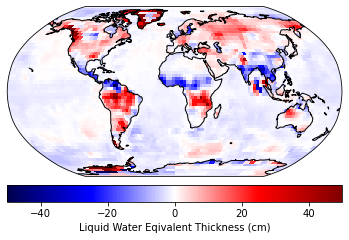

In [3]:
# make your figure here
fig=plt.figure()
proj = ccrs.Robinson()
ax1 = fig.add_subplot(projection=proj)
C = ax1.pcolormesh(lon, lat, lwe_thickness[0,:,:], transform=ccrs.PlateCarree(),
               vmin=-50, vmax=50 ,cmap='seismic')
plt.colorbar(C, orientation='horizontal', pad=0.04, label='Liquid Water Eqivalent Thickness (cm)')
ax1.coastlines(color='k')
plt.show()

**&#x1F914; Questions for consideration**

After you've made your plot, consider the following questions:
1. In the month you've chosen to plot, where do you see strong positive values? Negative values? Why?
2. What are the positive and negative values in reference to?
3. The lon-lat grid in the file is provided with a longitudinal and latitudinal spacing of 0.5 degree. However, some of the signals in the data are "blocky" and don't represent this resolution. Why?

## Part 2: Assessing Hotspot of Mass Change
In the plot above, we tend to see higher values on land than in the ocean. As a first assessment of where mass changes are most variable, we can compute the standard deviation of the LWET values. Reproduce your map above with these values. Be sure to use a sequential colorbar and stretch the color map to represent the data appropriately.

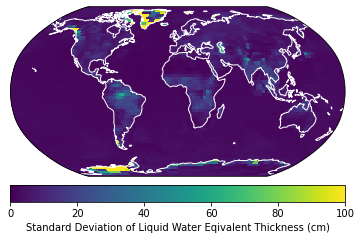

In [6]:
fig=plt.figure()
proj = ccrs.Robinson()
ax1 = fig.add_subplot(projection=proj)
C = ax1.pcolormesh(lon, lat, np.std(lwe_thickness[:,:,:],axis=0), transform=ccrs.PlateCarree(),
               vmin=0, vmax=100 ,cmap='viridis')
plt.colorbar(C, orientation='horizontal', pad=0.04, label='Standard Deviation of Liquid Water Eqivalent Thickness (cm)')
ax1.coastlines(color='white')
plt.show()

**&#x1F914; Question for consideration**

After you've made your plot, consider the following question: Where is the variability the strongest? What do these locations have in common?

## Part 3: Masking Land Data and Visualizing Ocean Changes

To investigate changes in ocean mass, we'll need to remove the signal from land. One way to visualize this ocean signal alone is to mask out the portion on land. Since this is a common calculation, the GRACE team provides a land mask in the distributed mascon file. Make a plot of the land mask here:


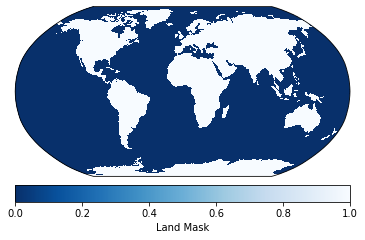

In [9]:
fig=plt.figure()
proj = ccrs.Robinson()
ax1 = fig.add_subplot(projection=proj)
C = ax1.pcolormesh(lon, lat, land_mask, transform=ccrs.PlateCarree(),
               vmin=0, vmax=1 ,cmap='Blues_r')
plt.colorbar(C, orientation='horizontal', pad=0.04, label='Land Mask')
plt.show()

The land mask can be applied to the data using numpy's `np.ma.masked_where` function. For example, the first time step of the mason solution can be masked as follows:

```
masked_lwe_thickness = np.ma.masked_where(land_mask==1, lwe_thickness[0,:,:])
```

Using this masking code, recreate your plot above with the land data masked out. Be sure to adjust your colorbar to be appropriate for the ocean-only data as needed.

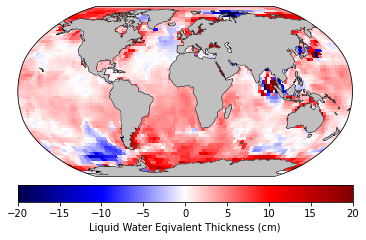

In [12]:
fig=plt.figure()
proj = ccrs.Robinson()
ax1 = fig.add_subplot(projection=proj)
masked_lwe_thickness = np.ma.masked_where(land_mask==1, lwe_thickness[-,:,:])
C = ax1.pcolormesh(lon, lat, masked_lwe_thickness, transform=ccrs.PlateCarree(),
               vmin=-20, vmax=20 ,cmap='seismic')
plt.colorbar(C, orientation='horizontal', pad=0.04, label='Liquid Water Eqivalent Thickness (cm)')
ax1.add_feature(cfeature.LAND, zorder=99, facecolor='silver')
ax1.coastlines(color='white')
ax1.coastlines(color='k')
plt.show()

**&#x1F914; Questions for consideration**

After you've made your plot, consider the following questions:
1. How does this change your assessment of ocean changes?
2. Try changing your time step to a new time period. What do you notice about the map? Why?

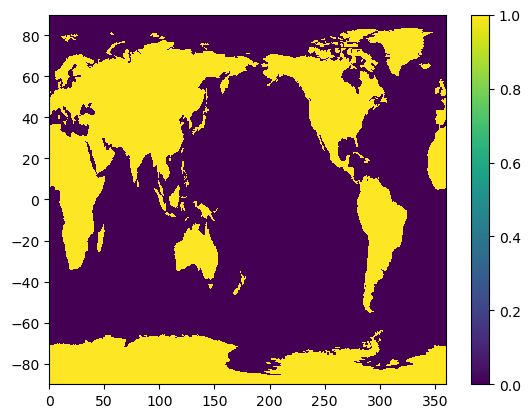

In [36]:
C = plt.pcolormesh(lon, lat, land_mask)
plt.colorbar(C)
plt.show()

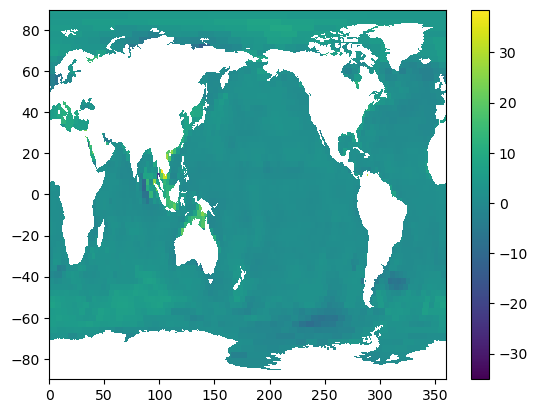

In [37]:
# Select the mass anomaly variable
lwe_masked = np.ma.masked_where(land_mask==1, lwe_thickness[100,:,:])
C = plt.pcolormesh(lon, lat, lwe_masked)
plt.colorbar(C)
plt.show()


## Part 4: Computing Global Ocean Mean Mass Anomaly

Next, we will compute the area-weighted average liquid water equivalent thickness over the global ocean. This average tells us how much water would need to be spread evenly over the ocean to produce the same mass anomaly. Since the data are on a latitude-longitude grid, grid cells near the equator represent a larger area than grid cells near the poles. The first step in our calculation will be to estimate the area of each grid cell.


### Computing areas
If we assume the Earth is a perfect sphere with radius $R=$6,371 km, it's fairly straight-forward to compute the area of each cell if we think of each cell as taking up a given proportion of the sphere. On one hand, the area of a vertical latitude band between $\phi_1$ and $\phi_0$ has area

$$
A_{\text{Longitude Band}} = A_{Earth} \left(\frac{\phi_1 - \phi_0}{2\pi}\right)  = 2 R^2 (\phi_1 - \phi_0)
$$

Further, a little trigonometry shows the the area of a portion of the sphere between the equator and a given latitude ($\theta$) is scaled by the *sin* of the latitude. Thus, in a given latitude band between $\theta_1$ and $\theta_0$, the fractional area is  

$$
A_{\text{Latitude Band}} = A_{Earth}\left(\frac{\sin (\theta_1) - \sin (\theta_0)}{2}\right)
$$

Putting these pieces together, we can compute the surface area of a given area of a sphere as 

$$
A_{patch} = R^2 (\phi_1 - \phi_0) (\sin (\theta_1) - \sin (\theta_0)) 
$$


In [15]:
# convert to radians
lon_bounds_rad = np.deg2rad(lon_bounds)
lat_bounds_rad = np.deg2rad(lat_bounds)

# make an array to store the area in each cell
R = 6371000
Area = np.zeros((360, 720))
for i in range(len(lon_bounds)-1):
    for j in range(len(lat_bounds)-1):
        Area[j,i] = R**2 * (lon_bounds_rad[i,1] - lon_bounds_rad[i,0]) * \
        (np.sin(lat_bounds_rad[j,1]) - np.sin(lat_bounds_rad[j,0])) 

### Global Mean Ocean Mass Anomaly Time Series

With the area of each grid cell in hand, we're ready to compute the global mean ocean mass anomaly time series. The mass anomaly at timestep $t$ is given by

$$
M_t = \frac{\sum_i^{I} \sum_j^{J} LWE_{i,j}A_{i,j}}{\sum_i^{I} \sum_j^{J} A_{i,j}}
$$

Here, $I$ and $J$ refer to the number of longitude and latitude values in the grid, $LWE_{i,j}$ is the grided liquid weight equivalent thickness in cell $(i,j)$, and $A_{i,j}$ is the area of that cell.

Using  this formula, compute the mass anomaly at each timestep. Be sure to exclude the data over land!

In [26]:
Area[land_mask==1] = 0

ocean_mass_anomaly_timeseries = np.zeros((np.shape(lwe_thickness)[0],))
for i in range(np.shape(lwe_thickness)[0]):
    ocean_mass_anomaly_timeseries[i] = np.sum(lwe_thickness[i,:,:]*Area) / np.sum(Area)

### Computing Time
Before we plot the global ocean mass anomaly time series, we'll need to know what each time step corresponds to. When we read in the time, this was referenced in "days since 2002-01-01". That's a convenient time record for calculations, but our calendar-focused brains would be much better with data. In the space below, make a list called `dates` that converts each time step to a given date. The `datetime` package we read in earlier is quite useful for this calculation:

In [27]:
dates = []
for i in range(len(days_since_2002)):
    dates.append(datetime(2002,1,1) + timedelta(days = days_since_2002[i]))

### Plotting the Global Ocean Mass Anomaly Timeseries

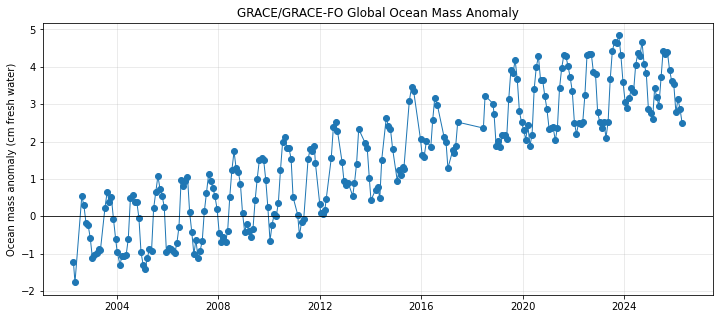

In [34]:
# Plot the global ocean mass time series
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dates, ocean_mass_anomaly_timeseries, 'o-', linewidth=1)
ax.axhline(0, color="k", linewidth=0.8)

ax.set_ylabel("Ocean mass anomaly (cm fresh water)")
ax.set_title("GRACE/GRACE-FO Global Ocean Mass Anomaly")
ax.grid(alpha=0.3)

plt.show()

**&#x1F914; Questions for consideration**

1. Is there a long-term increase or decrease in ocean mass over the record?
2. What is the approximate range of the seasonal cycle? Why is there a seasonal cycle?
3. Are there any gaps in the time series? Why?

## Part 5: Estimating Steric Height

In the section above, we compute changes in ocean mass since the start of the GRACE observations. Next, we'll compare this record to that for global mean sea level as measured by radar altimeters to estimate changes in steric height.

In Lab 10, we used sea surface height fields to estimate a time series of region or global mean sea level rise. Here, we will use a convenient product generated by JPL with this calculation already done. Navigate to the [NASA-SSH Global Mean Sea Level from Simple Gridded Sea Surface Height](https://podaac.jpl.nasa.gov/dataset/NASA_SSH_GMSL_INDICATOR) product page and download the most recent `NASA_SSH_GMSL_INDICATOR.txt` document. Be sure to put this in your data folder for this lab. 

After you've read in the data, write a quick script to read the data into a numpy array in the coding block below. You may need to inspect the file to determine the format (e.g. the number of header lines, expected number of columns, etc).

In [39]:
global_mean_slr = np.genfromtxt(os.path.join('data','NASA_SSH_GMSL_INDICATOR.txt'),
                                delimiter='    ', skip_header=42)

Once you've read in the data, make a plot here:

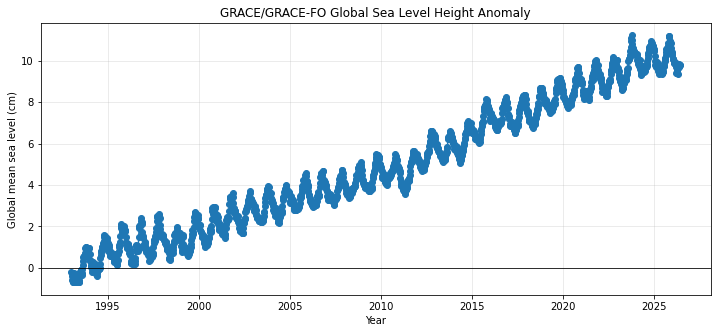

In [42]:
# Plot the global ocean mass time series
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(global_mean_slr[:,0], global_mean_slr[:,1], 'o-', linewidth=1.5, )
ax.axhline(0, color="k", linewidth=0.8)

ax.set_xlabel("Year")
ax.set_ylabel("Global mean sea level (cm)")
ax.set_title("GRACE/GRACE-FO Global Sea Level Height Anomaly")
ax.grid(alpha=0.3)

plt.show()

**&#x1F914; Questions for consideration**

1. How does the time period of this record compare to the GRACE record?
2. What is the time step between observations? How does this compare to the GRACE record?
3. What are the units of time in this record? How does this compare to the GRACE record?
4. What is the anomaly in this record in reference to? How does this compare to the GRACE record?

In [46]:
import datetime as dt

def YMD_to_DecYr(date):
    
    start_of_year = dt.datetime(year, 1, 1, 0, 0, 0)
    start_of_next_year = dt.datetime(year + 1, 1, 1, 0, 0, 0)
    
    year_length = (start_of_next_year - start_of_year).total_seconds()
    seconds_into_year = (date - start_of_year).total_seconds()
    
    decimal_fraction = seconds_into_year / year_length
    dec_yr = year + decimal_fraction
    
    return dec_yr

In [53]:
total_slr_homogenized = []
for b in range(np.shape(days_since_2002_bounds)[0]):
    start_date = datetime(2002,1,1) + timedelta(days = days_since_2002_bounds[b,0])
    end_date = datetime(2002,1,1) + timedelta(days = days_since_2002_bounds[b,1])
    start_dec_yr = YMD_to_DecYr(start_date.year, start_date.month, start_date.day)
    end_dec_yr = YMD_to_DecYr(end_date.year, end_date.month, end_date.day)
    indices = np.logical_and(total_slr[:,0]>=start_dec_yr, total_slr[:,0]<end_dec_yr)
    if np.sum(indices)>0:
        total_slr_homogenized.append(np.mean(total_slr[indices,1]))
    else:
        total_slr_homogenized.append(np.nan)
total_slr_homogenized=np.array(total_slr_homogenized)

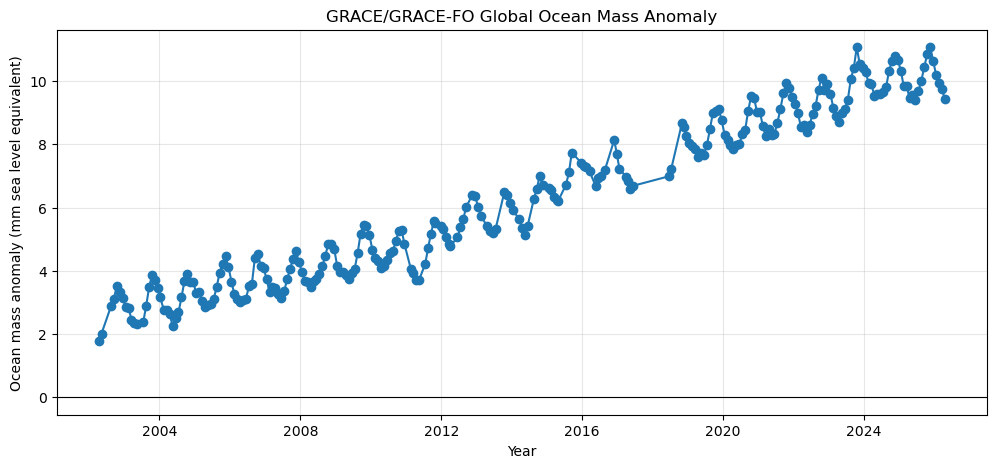

In [54]:
# Plot the global ocean mass time series
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dates, total_slr_homogenized, 'o-', linewidth=1.5, )
ax.axhline(0, color="k", linewidth=0.8)

ax.set_xlabel("Year")
ax.set_ylabel("Ocean mass anomaly (mm sea level equivalent)")
ax.set_title("GRACE/GRACE-FO Global Ocean Mass Anomaly")
ax.grid(alpha=0.3)

plt.show()


In [55]:
steric_height_anomaly = total_slr_homogenized - ssh_timeseries

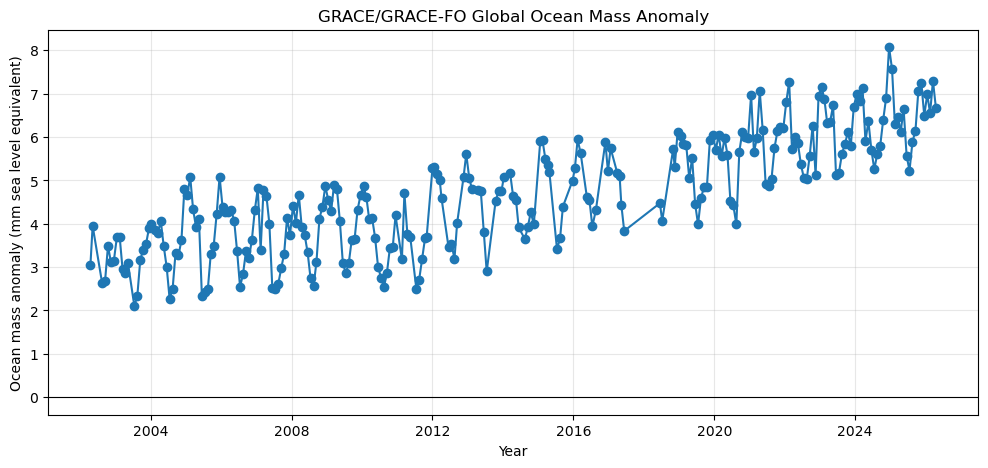

In [56]:
# Plot the global ocean mass time series
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dates, steric_height_anomaly, 'o-', linewidth=1.5, )
ax.axhline(0, color="k", linewidth=0.8)

ax.set_xlabel("Year")
ax.set_ylabel("Ocean mass anomaly (mm sea level equivalent)")
ax.set_title("GRACE/GRACE-FO Global Ocean Mass Anomaly")
ax.grid(alpha=0.3)

plt.show()


## Trend

## Summary

In this lab, we used GRACE/GRACE-FO mascon data to estimate the ocean mass contribution to global mean sea level. The key steps were:

1. Open the GRACE mascon netCDF file
2. Plot a monthly map of liquid water equivalent thickness anomaly
3. Build a simple ocean mask
4. Compute an area-weighted global ocean mean time series
5. Remove the seasonal cycle
6. Estimate a linear trend in mm/yr

The main scientific takeaway is that GRACE gives us a direct observational constraint on mass redistribution in the Earth system. For sea level studies, this makes GRACE an essential complement to satellite altimetry and ocean temperature/salinity observations.
